In [1]:
from datasets import load_dataset
dataset = load_dataset("sfarrukhm/intel-image-classification")


C:\Users\ssbih\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
type(dataset)

datasets.dataset_dict.DatasetDict

In [6]:
import numpy as np
from PIL import Image

# 1. Create empty lists
X_train_list = []
y_train_list = []

X_test_list = []
y_test_list = []

# 2. Loop through the 'train' compartment
for item in dataset['train']:
    # Convert PIL Image to NumPy and Resize to 150x150
    img = item['image'].convert('RGB').resize((150, 150))
    X_train_list.append(np.array(img))
    y_train_list.append(item['label'])

# 3. Final Conversion to NumPy Arrays
X_train = np.array(X_train_list, dtype='float32') / 255.0 # Normalizing here!
y_train = np.array(y_train_list)

print(X_train.shape) # Expected: (14034, 150, 150, 3)

for item in dataset['test']:
    # Convert PIL Image to NumPy and Resize to 150x150
    img = item['image'].convert('RGB').resize((150, 150))
    X_test_list.append(np.array(img))
    y_test_list.append(item['label'])

# 3. Final Conversion to NumPy Arrays
X_test = np.array(X_test_list, dtype='float32') / 255.0 # Normalizing here!
y_test  = np.array(y_test_list)

print(X_test.shape) # Expected: (14034, 150, 150, 3)


(14034, 150, 150, 3)
(3000, 150, 150, 3)


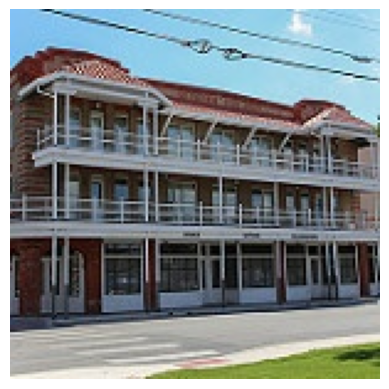

In [7]:
import matplotlib.pyplot as plt

plt.imshow(X_train[2])
plt.axis("off")
plt.show()

In [8]:
print(X_train.min(),X_train.max())

0.0 1.0


In [9]:
mean = X_train.mean()
std = X_train.std()

print(mean)
print(std)

0.44716802
0.27914926


In [10]:
X_train = (X_train - mean)/std
X_test = (X_test - mean) / std 

In [11]:
mean = X_train.mean()
std = X_train.std()

print(mean)
print(std)

-1.4759569e-05
1.000005


In [12]:
import torch
from torch.utils.data import TensorDataset

X_train_t = torch.from_numpy(X_train).float()
y_train_t = torch.from_numpy(y_train).long()

X_test_t = torch.from_numpy(X_test).float()
y_test_t = torch.from_numpy(y_test).long()

train_dataset = TensorDataset(X_train_t,y_train_t)
test_dataset = TensorDataset(X_test_t,y_test_t)

In [13]:
from torch.utils.data  import DataLoader

batch_size  =16 
train_loader = DataLoader(train_dataset, batch_size, shuffle = True)
test_loader = DataLoader(test_dataset ,batch_size, shuffle= False)

In [14]:
import numpy as np

num_classes = len(np.unique(y_train))
print(num_classes)

6


In [33]:
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),   # (N,32,112,112)

            nn.Conv2d(32, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),   # (N,64,56,56)

            nn.Conv2d(64, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),   # (N,128,28,28)

            nn.Conv2d(128, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),   # (N,256,14,14)

            nn.Conv2d(256, 512, 3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),   # (N,512,7,7)
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))  # (N,128,1,1)

        self.classifier = nn.Sequential(
            nn.Flatten(),          # (N,128)
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),

            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, num_classes)
            
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x

model = SimpleCNN()

In [34]:
import torch.optim as optim 
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.3, patience=2, min_lr=1e-6
) 

In [35]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("Using:", device)

Using: cuda


In [36]:
# define once (outside loop)
mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(1,3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225], device=device).view(1,3,1,1)

def tain_one_epoch(model, loader):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for x, y in loader:
        x = x.to(device).float()
        y = y.to(device).long()

        # NHWC -> NCHW
        if x.ndim == 4 and x.shape[-1] == 3:
            x = x.permute(0, 3, 1, 2).contiguous()

        # x is already 0..1 (you confirmed). Now normalize:
        x = (x - mean) / std

        # simple augmentation (optional but helps)
        if torch.rand(1).item() < 0.5:
            x = torch.flip(x, dims=[3])  # horizontal flip

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    return total_loss/total, correct/total


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for x, y in loader:
        x = x.to(device).float()
        y = y.to(device).long()

        if x.ndim == 4 and x.shape[-1] == 3:
            x = x.permute(0, 3, 1, 2).contiguous()

        x = (x - mean) / std

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)

    return total_loss/total, correct/total

In [37]:
import torch
train_loss,test_loss = [],[]
train_acc,test_acc = [],[]
best_acc = 0


epochs =20 
for epoch in range(1,epochs + 1):

    
   tr_loss,tr_acc = tain_one_epoch (model,train_loader)
   te_loss,te_acc = evaluate(model,test_loader)

    # each epoch after validation:
   scheduler.step(float(te_loss))  

   train_loss.append(tr_loss)
   test_loss.append(te_loss)
   train_acc.append(tr_acc)
   test_acc.append(te_acc)
   print(
        f"Epoch {epoch:02d} | Train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
        f"Test loss {te_loss:.4f} acc {te_acc:.4f}"
    ) 
   if(te_acc>best_acc):
       best_acc = te_acc
       torch.save(model.state_dict(), "best_model.pth")
       print("Best model saved")

Epoch 01 | Train loss 1.0939 acc 0.6626 | Test loss 0.9907 acc 0.7167
Best model saved
Epoch 02 | Train loss 0.9221 acc 0.7615 | Test loss 0.8200 acc 0.8063
Best model saved
Epoch 03 | Train loss 0.8767 acc 0.7892 | Test loss 0.7802 acc 0.8540
Best model saved
Epoch 04 | Train loss 0.8385 acc 0.8055 | Test loss 0.8590 acc 0.7983
Epoch 05 | Train loss 0.7438 acc 0.8514 | Test loss 0.7040 acc 0.8680
Best model saved
Epoch 06 | Train loss 0.7141 acc 0.8659 | Test loss 0.6857 acc 0.8727
Best model saved
Epoch 07 | Train loss 0.6999 acc 0.8737 | Test loss 0.6836 acc 0.8787
Best model saved
Epoch 08 | Train loss 0.6590 acc 0.8955 | Test loss 0.6490 acc 0.8917
Best model saved
Epoch 09 | Train loss 0.6445 acc 0.9022 | Test loss 0.6425 acc 0.8967
Best model saved
Epoch 10 | Train loss 0.6403 acc 0.9027 | Test loss 0.6394 acc 0.8973
Best model saved
Epoch 11 | Train loss 0.6212 acc 0.9104 | Test loss 0.6332 acc 0.8990
Best model saved
Epoch 12 | Train loss 0.6170 acc 0.9152 | Test loss 0.6316 a

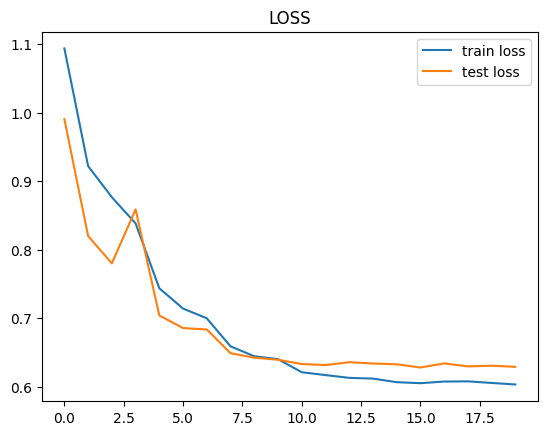

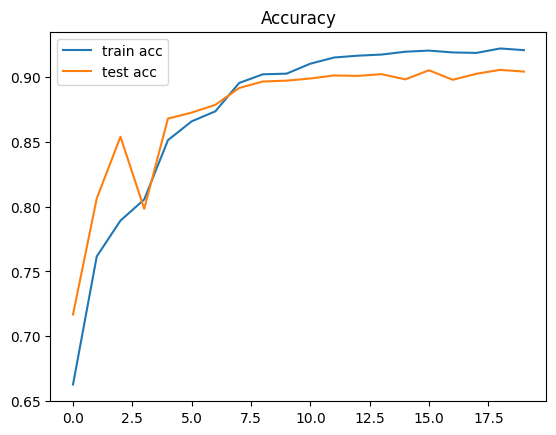

In [38]:
import matplotlib.pyplot as plt
plt.figure
plt.plot(train_loss, label = "train loss")
plt.plot(test_loss, label = "test loss")
plt.legend()
plt.title("LOSS")
plt.show()

plt.figure
plt.plot(train_acc, label = "train acc")
plt.plot(test_acc, label = "test acc")
plt.legend()
plt.title("Accuracy")
plt.show()